# rStar (Self-play muTuAl Reasoning)

## Components:
1. MCTS --> Smart gambler (could increase simulations per iteration to build confidence)
2. Beam Search --> Focuses the race, keeping the `k` most promising solution trajectories at each step
3. Rich Set of Reasoning Actions --> Promote human like decision making
4. Mutual Consistency -->  Peer2peer feedback (if you and your friend got the same answer. Then you have a higher confidence you are both right)
5. Tree Nodes --> Act as a logbook entry (stores all the vital information about a specific point in the problem solving process)
6. LLM --> Powerful AI consultant/expert
7. Smart judge --> Checks if 2 outputs are equivalent (0.5 vs 1/2 vs \frac{1}{2})

In [1]:
from getpass import getpass
from dotenv import load_dotenv
import os
# Set up LLM connection

load_dotenv()
groq_key = os.getenv("GROQ_KEY", "Empty")

model = getpass("Enter the model name: ")
api_endpoint = getpass("Enter the API endpoint (default: https://api.openai.com): ")
#- Model should be "llama3-8b-8192"
#- endpoint should be "https://api.groq.com/openai"

api_endpoint = api_endpoint if api_endpoint else "https://api.openai.com"
api_key = groq_key

openai_api_base = f"{api_endpoint}/v1"

print(f"Model: {model}")
print(f"API Endpoint: {api_endpoint}")
print(f"OpenAI API Base: {openai_api_base}")
if api_key == "Empty":
    print("No API key needed.")
else:
    print(f"API Key Set")

Model: llama3-8b-8192
API Endpoint: https://api.groq.com/openai
OpenAI API Base: https://api.groq.com/openai/v1
API Key Set


In [38]:
from openai import OpenAI
import re # support for regex

# Initialize the OpenAI API client
client = OpenAI(
    api_key=api_key,
    base_url=openai_api_base
)

def chat_completion_request_openai(prompt): # function that will call the OpenAI API
    messages = [
        {"role": "user", "content": prompt}
    ]
    # Create chat completions using the OpenAI client
    chat_response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=1.0,
        max_tokens=1500,
    )

    # Extract the completion text from the response
    if chat_response.choices:
        completion_text = chat_response.choices[0].message.content
    else:
        completion_text = "No response from the model."
    return completion_text

# Test the endpoint
if __name__ == "__main__":
    # Test the function
    prompt = "Return an array of string, where each string is a season"
    chat_response = chat_completion_request_openai(prompt)
    print(f"Prompt: {prompt}\n")
    print(f"Response: {chat_response}")

Prompt: Return an array of string, where each string is a season

Response: Here is a simple array of strings, where each string is a season:
```
["Spring", "Summer", "Autumn", "Winter"]
```
Let me know if you need anything else!


In [37]:
import re

def rate_final_answer(question, state, expected_answer="x = 1.6, y = 5.7"):
    rating_prompt = (
        f"Question: {question}\n"
        f"Answer: {state}\n"
        f"Ground-truth Answer: {expected_answer}\n"
        "As an expert on this topic, please provide a detailed critique of the answer. "
        "Rate the answer based on correctness, completeness, and logical consistency. "
        "First state whether the answer is correct or incorrect. "
        "Provide only a critique, not a suggested answer. "
        "Then, rate the answer on a scale of 0 to 100. "
        "The response MUST be in the following format:\n"
        "Critique: <detailed critique>\n"
        "Rating: <numeric rating>\n"
    )
    rating_response = chat_completion_request_openai(rating_prompt)

    try:
        match = re.search(r"Rating:\s*(\d+)", rating_response) # Extract rating to be used in the UCT calculation
        if match:
            rating = int(match.group(1))
            if rating > 95: # Paper limits the rating to a maximum of 95 (maybe 96+ causes poor MCTS performance)
                rating = 95
            rating = float(rating)/100
        else:
            raise ValueError("Rating not found in the response.")
    except Exception as e:
        print(f"Error extracting rating: {e}")
        print(f"Rating response was: {rating_response}")
        rating = 0

    return rating # Simulated trajectory is not saved, only the rating is used to backpropagate the reward

In [36]:
# Create prompt based on provided Action
def create_prompt_and_execute(question, state, action):
    prompts = {
            "A1": f"Question: {question}\n"
        f"Existing Reasoning Steps: {state}\n"
        "Please propose the next one-step thought to advance the reasoning process. "
        "Focus only on the immediate next step without solving the entire problem. "
        "Ensure the step is logically consistent with the existing reasoning steps. "
        "Do not provide the final answer or skip steps. Unless the next step clearly results in the final answer. "
        "Think step by step and provide only one reasoning step.",
            "A2": f"Question: {question}\n"
        f"Existing Reasoning Steps: {state}\n"
        "You must now complete the reasoning process to solve the problem entirely. "
        "Think step by step and ensure logical consistency with the existing reasoning steps. "
        "Provide the final answer at the end of your response in the following format: 'The Final Answer is: <your answer>'. "
        "Do not skip steps or provide incomplete reasoning. "
        "Ensure that your response is comprehensive and logically sound.",
            "A3": f"Question: {question}\n"
        f"Existing Reasoning Steps: {state}\n"
        "Please propose the next sub-question to simplify the problem further. "
        "After proposing the sub-question, provide its answer. "
        "Ensure the sub-question logically follows from the existing reasoning steps. "
        "Do not solve the entire problem or skip intermediate sub-questions. "
        "Think step by step and provide only one sub-question and its answer.",
            "A4": f"Sub-Question: {question}\n"
        f"Existing Reasoning Steps: {state}\n"
        "The sub-question might have been answered incorrectly. "
        "Please re-answer the last sub-question using few-shot chain-of-thought reasoning. "
        "Focus only on answering the sub-question accurately and logically. "
        "Do not reference the original answer or provide additional sub-questions. "
        "Provide a detailed explanation and a verified final answer to the sub-question. "
        "Do not provide the final answer to the original question or skip steps. Unless answering the sub-question clearly results in the final answer to the original question. "
        "Ensure logical consistency in your reasoning.",
            "A5": f"Original Question: {question}\n"
        "The original question might be misunderstood or unclear. "
        "Please rephrase the question to make it simpler and easier to understand. "
        "Clearly list all conditions and constraints provided in the problem statement. "
        "Ensure that no information is lost or altered during the rephrasing process. "
        "Do not solve the question or provide an answer.",
    }
    if action != 'A2':
        prompt = (
            prompts[action] +
            f"\n\nIMPORTANT: If your reasoning leads to the final answer of the original question, you MUST explicitly state it in the following format at the end of your response: 'The Final Answer is: <your answer>'."
            "\nIf you are answering a sub-question, you MUST clearly provide the final answer to that sub-question in the following format instead: 'The Sub-Question Answer is: <your answer>'\n"
            "\nEnsure that this format is strictly followed to avoid ambiguity.\n"
            "\nDo not include the text 'The Final Answer is: <your answer>' or 'The Sub-Question Answer is: <your answer>' in your response otherwise\n"
        )
    else:
        prompt = prompts[action]

    action_response = chat_completion_request_openai(prompt)

    cumulative_state = state + "\n\n-------------------NEXT STEP-------------------\n\n" + action_response # Previous state + new_state (this should be optimized in the future to better effect downstream nodes, ESPECIALLY for larger problems)

    # Initialize rating as -1
    rating = -1
    try:
        if re.search(r"The Final Answer is:", cumulative_state):
            rating = rate_final_answer(question, cumulative_state)
    except Exception as e:
        print(f"Error checking for final answer: {e}")

    return cumulative_state, rating


In [35]:
import re

# Simulate a Node then rate the response (used to backpropagate the reward of an expanded node)
def simulate_then_rate(question, state, expected_answer="Not provided"):
    prompt = (
        f"Question: {question}\n"
        f"Existing Reasoning Steps: {state}\n"
        "Please propose the remaining reasoning steps to solve the problem completely. "
        "Think step by step and ensure logical consistency with the existing reasoning steps. "
        "Provide the final answer at the end of the reasoning process. "
        "Do not skip steps or provide incomplete reasoning."
    )
    simulated_answer = chat_completion_request_openai(prompt)
    # print(f"Simulated Answer:\n{simulated_answer}\n")

    # print(f"Total state:\n{state }\n\n{simulated_answer}\n")

    rating_prompt = (
        f"Question: {question}\n"
        f"Answer: {state}\n\n{simulated_answer}\n"
        f"Ground-truth Answer: {expected_answer}\n"
        "As an expert on this topic, please provide a detailed critique of the answer. "
        "Rate the answer based on correctness, completeness, and logical consistency. "
        "First state whether the answer is correct or incorrect. "
        "Provide only a critique, not a suggested answer. "
        "Then, rate the answer on a scale of 0 to 100. "
        "The response MUST be in the following format:\n"
        "Critique: <detailed critique>\n"
        "Rating: <numeric rating>\n"
    )
    rating_response = chat_completion_request_openai(rating_prompt)
    # print(f"Rating response:\n{rating_response}\n")

    # Extract the rating
    try:
        match = re.search(r"Rating:\s*(\d+)", rating_response) # Extract rating to be used in the UCT calculation
        if match:
            rating = int(match.group(1))
            if rating > 95: # Paper limits the rating to a maximum of 95 (maybe 96+ causes poor MCTS performance)
                rating = 95
            rating = float(rating)/100
        else:
            raise ValueError("Rating not found in the response.")
    except Exception as e:
        print(f"Error extracting rating: {e}")
        print(f"Rating response was: {rating_response}")
        rating = 0

    return rating # Simulated trajectory is not saved, only the rating is used to backpropagate the reward

# Test the function
if __name__ == "__main__":
    # Test the function
    question = "Solve the system of linear equations:\n\nx + 2y = 13\n3x - 4y = -18"
    ground_truth_answer = "x = 1.6, y = 5.7"
    # state = (
    #     "To solve the system of linear equations, we can use substitution or elimination methods.\n\n"
    #     "First, we will multiply the first equation by 3 and the second equation by 1 to make the coefficients of x in both equations equal:\n"
    #     "(3)(x + 2y) = (3)(13)\n"
    #     "(1)(3x - 4y) = (1)(-18)"
    # )
    state = (
        "To solve the system of linear equations, we can use substitution or elimination methods.\n\n"
        "First, we will multiply the first equation by 3 and the second equation by 1 to make the coefficients of x in both equations equal:\n"
        "(3)(x + 2y) = (3)(13)\n"
        "(1)(3x - 4y) = (1)(-18)\n\n"
        "Now, we will subtract the second equation from the first equation to eliminate the x variable:\n"
        "(3x + 6y) - (3x - 4y) = 39 - (-18)\n\n"
        "This simplifies to:\n"
        "10y = 57"
    )
    rating = simulate_then_rate(question, state, ground_truth_answer)
    print(f"Rating: {rating}")

    # Question URL --> https://huggingface.co/datasets/camel-ai/math/viewer/default/train?p=2&views%5B%5D=train&row=203
    # Ground-truth answer to the above question:
    # x = 1.6
    # y = 5.7

    # This is working as expected.

Rating: 0.8


In [34]:
import math
import random
import numpy as np

max_children = 4
ground_truth_answer = "x = 1.6, y = 5.7"

class Node:
    def __init__(self, question, state, action=None, parent=None):
        self.state = state
        self.action = action # Action taken to reach this node
        self.parent = parent
        self.original_question = question
        self.current_question = question
        self.is_answered = False
        self.children = []
        self.visits = 0
        self.value = 0
        # Add unique identifier to the node

    def is_fully_expanded(self):
        # Right now every action is expanded --> so as long as there are children, the node is fully expanded (could change this if you want multiple A1,A2,A3 for example coming from 1 node)
        return len(self.children) > 0 or self.is_answered
    
    def best_child(self, exploration_weights=1.41):
        choices_weights = []
        for child in self.children:
            if child.is_answered: # If the child is a terminal node, we don't want to explore it
                weight = -1
            elif child.visits == 0:
                weight = float('inf') # Prioritize unexplored nodes
            else:
                weight = (child.value / child.visits) + exploration_weights * math.sqrt(math.log(self.visits) / child.visits) # UCT calculation
                # Exploration term --> (child.value / child.visits) --> basically the average reward of the child
                # Exploitation term --> exploration_weights * math.sqrt(2 * math.log(self.visits) / child.visits) --> will be very high for unexplored nodes which will encourage exploration down that path
            choices_weights.append(weight)
        return self.children[np.argmax(choices_weights)]
    
    def most_visited_child(self): # This is used to pull the best trajectory from the MCTS tree once its generation is done (best trajectory == most likely to be the correct answer)
        return max(self.children, key=lambda child: child.visits) # Return the child with the most visits
    
    def add_child(self, child_node): # Utility function used to expand the tree
        self.children.append(child_node)

class rStar:
    def __init__(self, question, num_rollouts=1, max_depth=3, iterations=2):
        self.root = Node(question, "Begin answering the question")
        self.question = question
        self.num_rollouts = num_rollouts
        self.max_depth = max_depth
        self.iterations = iterations # Need to bound process by max_depth later

    def search(self):
        for i in range (self.iterations):
            print(f"Iteration {i+1}/{self.iterations}")
            node = self.select(self.root)
            print(f"Selected node: {node.action}")
            if node.action == 'A2' and not node.is_answered: # Error occured in previous A2 prompt
                reward = self.complete_A2(node, ground_truth_answer)
                node.is_answered = True
                self.backpropagate(node, reward)
                continue
            if not node.is_fully_expanded():
                random_child = self.expand(node)
            reward = self.simulate(random_child)
            print(f"Simulated reward: {reward}")
            self.backpropagate(random_child, reward) # Backpropagate from the child upwards
            print("=================================================")
        print(f"Visits to most visited child: {self.root.most_visited_child().visits}")
        return self.root.most_visited_child().state

    def select(self, node):
        while node.is_fully_expanded() and node.children:
            node = node.best_child() # Must check that the node is not answered in the best_child function
        return node
    
    def expand(self, node): # Working as exptected (but might have to fix the state the children are initialized with)
        actions = self.get_valid_actions(node)
        print(f"Node action: {node.action}\nValid actions: {actions}\n")

        if node.action == "A2": # Should never be reached since this is accounted for in the best_child function
            print("A2 is a terminal action, no further expansion.")
            return # Terminal node
        
        for action in actions:  # Expand every valid action
            action_prompt_result, rating = create_prompt_and_execute(node.current_question, node.state, action)
            if rating != -1:
                print("Is Answered, Rating:", rating)
            print(f"{action} response:\n\n {action_prompt_result}\n------------------------------------------")
            child_node = Node(node.original_question, action_prompt_result, action=action, parent=node)
            if rating != -1:
                child_node.is_answered = True
            node.add_child(child_node)
            if child_node.is_answered:
                self.backpropagate(child_node, rating) # Backpropagate the reward to the parent node of answered children

        # Any answered nodes should not be returned here to be simulated
        unanswered_children = [child for child in node.children if not child.is_answered]
        return random.choice(unanswered_children) # Return a random unanswered child, which will be simulated
    
    def simulate(self, node):
        # Have a check to see if the node is a terminal node (already answered) --> then just rate the node without simulating
        print(f"Simulating node: {node.action}")
        total_rating = 0
        for i in range(self.num_rollouts):
            rating = simulate_then_rate(node.original_question, node.state, ground_truth_answer)
            total_rating += rating
            print(f"Simulation {i+1}/{self.num_rollouts} rating: {rating}")
        return round(total_rating / self.num_rollouts, 2) # Return the average rating of the rollouts
    
    def backpropagate(self, node, reward):
        while node is not None:
            node.visits += 1
            node.value += reward
            node = node.parent

    def get_valid_actions(self, node): # Utility function
        actions = []

        if node.parent is None: # Root node
            actions = ["A1", "A2", "A3", "A5"]
        else:
            if node.action == "A1":
                actions = ["A1", "A2", "A3"]
            elif node.action == "A2":
                actions = []
            elif node.action == "A3":
                actions = ["A1", "A2", "A3", "A4"]
            elif node.action == "A4":
                actions = ["A1", "A2", "A3"]
            elif node.action == "A5":
                actions = ["A1", "A2", "A3"]
        
        return actions

    def complete_A2(self, node, expected_answer="Not provided"):
        prompt = (
            f"Question: {node.original_question}\n"
            f"Existing Reasoning Steps: {node.state}\n"
            "Please propose the remaining reasoning steps to solve the problem completely. "
            "Think step by step and ensure logical consistency with the existing reasoning steps. "
            "Provide the final answer at the end of the reasoning process. "
            "You MUST explicitly state it in the following format at the end of your response: 'The Final Answer is: <your answer>'. "
            "Do not skip steps or provide incomplete reasoning. "
        )
        rest_of_answer = chat_completion_request_openai(prompt)
        rating_prompt = (
            f"Question: {node.original_question}\n"
            f"Answer: {node.state}\n\n{rest_of_answer}\n"
            f"Ground-truth Answer: {expected_answer}\n"
            "As an expert on this topic, please provide a detailed critique of the answer. "
            "Rate the answer based on correctness, completeness, and logical consistency. "
            "First state whether the answer is correct or incorrect. "
            "Provide only a critique, not a suggested answer. "
            "Then, rate the answer on a scale of 0 to 100. "
            "The response MUST be in the following format:\n"
            "Critique: <detailed critique>\n"
            "Rating: <numeric rating>\n"
        )
        rating_response = chat_completion_request_openai(rating_prompt)
        node.state = node.state+"\n\n"+rest_of_answer # Append the rest of the answer to the state

        # Extract the rating
        try:
            match = re.search(r"Rating:\s*(\d+)", rating_response) # Extract rating to be used in the UCT calculation
            if match:
                rating = int(match.group(1))
                if rating > 95: # Paper limits the rating to a maximum of 95 (maybe 96+ causes poor MCTS performance)
                    rating = 95
                rating = float(rating)/100
            else:
                raise ValueError("Rating not found in the response.")
        except Exception as e:
            print(f"Error extracting rating: {e}")
            print(f"Rating response was: {rating_response}")
            rating = 0

        return rating # Simulated trajectory is not saved, only the rating is used to backpropagate the reward
        

# TODO: Make sure when other actions that are not A2 finish, answering the question --> They are also marked as answered (& reward is backpropagated)

# TODO implementation of post-processing steps:
"""
Extract full-trajectories when rStar is done executing

Rate trajectories

Mutual consistency --> to make sure full-trajectories are logically sound with higher confidence

MAYBE --> go to every non terminal node and one-shot a solution from there to make sure every trajectory is complete
"""
# TODO --> Add some logic for when the selected node is None (this should not happen, but just in case), but this is happening every so often (need to gracefully handle this, especially for running larger iterations so we don't lose time)

# TODO:
"""
1. Implement this for 1 coding problem 
2. Experiment between having multiple same actions coming from the same node
3. See if the errors made seem to be human-like or just super random (and make no logical sense)
4. Try out different models (llama3-8b-8192, llama3-70b-8192, llama3-70b-4096)
5. Try to further optimize prompts for A1, A2, A3, A4, A5, and some other things.
"""
# TODO: running into this issue where A2 isn't being fullshotted properly --> complete A2s when you see they are not complete (since we cannot prevent every occurence of this)


'\n1. Implement this for 1 coding problem \n2. Experiment between having multiple same actions coming from the same node\n3. See if the errors made seem to be human-like or just super random (and make no logical sense)\n4. Try out different models (llama3-8b-8192, llama3-70b-8192, llama3-70b-4096)\n5. Try to further optimize prompts for A1, A2, A3, A4, A5, and some other things.\n'

In [39]:
# Test rStar class
question = "Solve the system of linear equations:\n\nx + 2y = 13\n3x - 4y = -18"
rstar = rStar(question, num_rollouts=2, max_depth=3, iterations=3)
best_answer = rstar.search()
print(f"Best answer:\n{best_answer}")

Iteration 1/3
Selected node: None
Node action: None
Valid actions: ['A1', 'A2', 'A3', 'A5']

A1 response:

 Begin answering the question

-------------------NEXT STEP-------------------

I'll propose the next one-step thought to advance the reasoning process.

Multiply the two equations by necessary multiples such that the coefficients of y's in both equations are the same, i.e., 2.
------------------------------------------
Is Answered, Rating: 0.2
A2 response:

 Begin answering the question

-------------------NEXT STEP-------------------

Let's begin by solving the given system of linear equations.

Step 1: Write down the equations:

x + 2y = 13 ... (Equation 1)
3x - 4y = -18 ... (Equation 2)

Step 2: Multiply Equation 1 by 3 to make the coefficients of x in both equations the same:

3x + 6y = 39 ... (Multiplied Equation 1 by 3)

Now we have:

3x + 6y = 39 ... (Equation 3)
3x - 4y = -18 ... (Equation 2)

Step 3: Add Equation 2 and Equation 3 to eliminate the variable x:

(3x + 6y = 

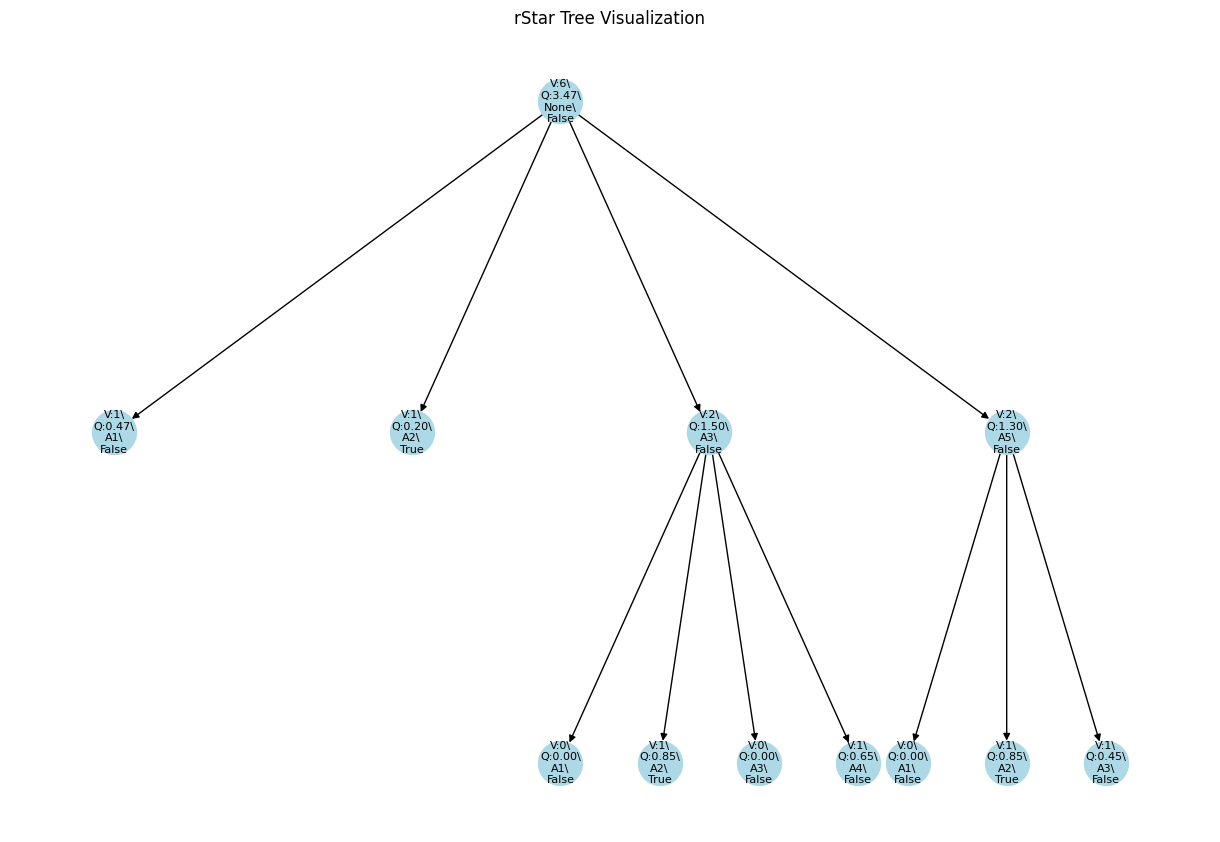

In [40]:
# Visualize rStar tree
import networkx as nx
import matplotlib.pyplot as plt

# Tidy tree layout algorithm --> Reingold-Tilford layout
def tidy_tree_layout(tree, root=None, x=0, y=0, dx=1.0, positions=None, level=0, spacing=1.5):
    if positions is None:
        positions = {}
    positions[root] = (x, y)
    children = list(tree.successors(root))
    if children:
        width = dx * (len(children) - 1) * spacing
        next_x = x - width / 2
        for child in children:
            tidy_tree_layout(tree, child, next_x, y - 1, dx / 3, positions, level + 1, spacing)
            next_x += dx * spacing
    return positions

def visualize_rstar_tree(mcts, max_nodes=100):
    graph = nx.DiGraph()
    node_labels = {}
    node_counter = [0]
    node_ids = {}

    def add_edges(node, parent_id=None):
        if node_counter[0] >= max_nodes:
            return
        node_id = node_counter[0]
        node_counter[0] += 1
        node_ids[node] = node_id
        label = f"V:{getattr(node, 'visits', '?')}\\\nQ:{getattr(node, 'value', '?'):.2f}\\\n{getattr(node, 'action', '?')}\\\n{getattr(node, 'is_answered', '?')}"
        node_labels[node_id] = label
        graph.add_node(node_id)
        if parent_id is not None:
            graph.add_edge(parent_id, node_id)
        for child in getattr(node, 'children', []):
            add_edges(child, node_id)

    add_edges(mcts.root)
    pos = tidy_tree_layout(graph, root=0, dx=2.0, spacing=1.5)
    plt.figure(figsize=(12, 8))
    nx.draw(
        graph,
        pos,
        with_labels=False,
        node_size=1000,  # Reduced node size
        node_color="lightblue"
    )
    nx.draw_networkx_labels(graph, pos, labels=node_labels, font_size=8)  # Reduced font size
    plt.title("rStar Tree Visualization")
    plt.axis('off')
    plt.show()

# Example usage
visualize_rstar_tree(rstar)